
# 1. Objetivo y contexto

Se ha utilizado un conjunto de datos, proveniente de Kaggle, de una empresa de comercio electrónico. Se busca principalmente identificar a los clientes que tienen más probabilidades de irse del negocio, para realizar las sugerencias más idóneas ante este problema.

# 2. Carga de datos y diccionario

In [52]:
import pandas as pd
df = pd.read_csv("../../data/data_ecommerce_customer_churn.csv") # Carga del dataset

In [53]:
df.shape

(3941, 11)

Este dataset cuenta con 3941 filas (clientes) y con 11 columnas (variables).

In [54]:
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   str    
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   str    
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 338.8 KB


El dataset cuenta con 11 columnas, cada columna representa lo siguiente:

- Tenure : Tiempo que un cliente permanece en la empresa (numérico)
- WarehouseToHome : Distancia entre el almacén y el domicilio del cliente (numérica)
- NumberOfDeviceRegistered : Número total de dispositivos registrados a nombre de un cliente específico (numérico)
- PreferedOrderCat : Categoría de pedido preferida de un cliente en el último mes (categórica)
- SatisfactionScore : Puntuación de satisfacción del cliente sobre el servicio (numérica)
- MaritalStatus : Estado civil de un cliente (categórico)
- NumberOfAddress : Número total de direcciones añadidas a un cliente concreto (numérico)
- Complain : Indica si se ha presentado alguna queja en el último mes (binario)
- DaySinceLastOrder : Días transcurridos desde el último pedido del cliente (numérico)
- CashbackAmount  : Reembolso promedio del último mes (numérico)
- Churn : Indicador de cambio de cliente (variable objetivo, binaria)


# 3. Limpieza básica

In [56]:
df.isnull().sum()

Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

In [57]:
df["Tenure"] = df["Tenure"].fillna(df["Tenure"].median())
df["WarehouseToHome"] = df["WarehouseToHome"].fillna(df["WarehouseToHome"].median())
df["DaySinceLastOrder"] = df["DaySinceLastOrder"].fillna(df["DaySinceLastOrder"].median())

In [58]:
df.isnull().sum()

Tenure                      0
WarehouseToHome             0
NumberOfDeviceRegistered    0
PreferedOrderCat            0
SatisfactionScore           0
MaritalStatus               0
NumberOfAddress             0
Complain                    0
DaySinceLastOrder           0
CashbackAmount              0
Churn                       0
dtype: int64

In [59]:
df.describe()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3941.000000,3941.000000,3941.000000,3941.000000,3941.000000,3941.000000,3941.000000,3941.000000,3941.000000
mean,10.028165,15.579802,3.679269,3.088302,4.237757,0.282416,4.448871,176.707419,0.171023
std,8.290290,8.275800,1.013938,1.381832,2.626699,0.450232,3.583909,48.791784,0.376576
min,0.000000,5.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,9.000000,3.000000,2.000000,2.000000,0.000000,2.000000,145.700000,0.000000
50%,9.000000,14.000000,4.000000,3.000000,3.000000,0.000000,3.000000,163.340000,0.000000
75%,15.000000,20.000000,4.000000,4.000000,6.000000,1.000000,7.000000,195.250000,0.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,1.000000,46.000000,324.990000,1.000000


# 4. Análisis univariado

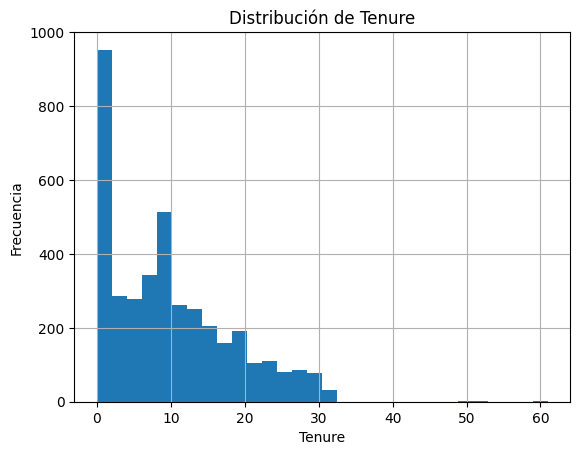

In [86]:
import matplotlib.pyplot as plt
from src.plots import plot_hist, plot_hist_by_churn

plot_hist(df, "Tenure")
plt.show()

In [ ]:
plt.savefig("../reports/figures/tenure_hist.png")
plt.close()

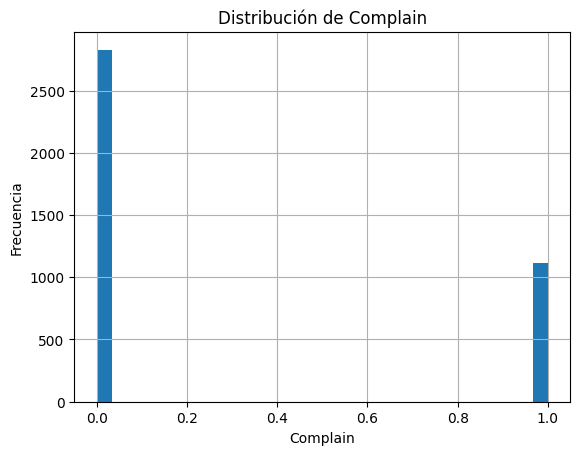

In [87]:
import matplotlib.pyplot as plt
from src.plots import plot_hist, plot_hist_by_churn

plot_hist(df, "Complain")
plt.show()


In [ ]:
plt.savefig("../reports/figures/complain_hist.png")
plt.close()

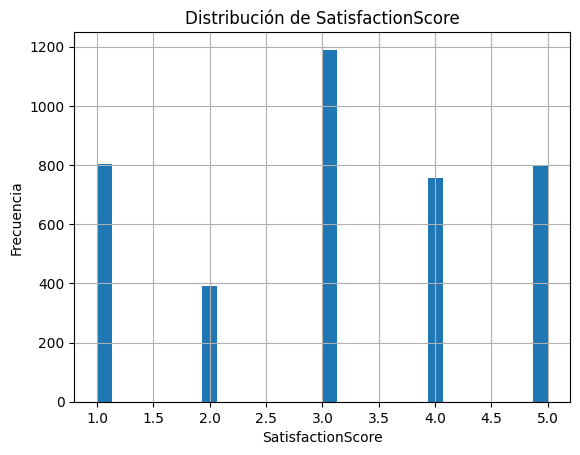

In [88]:
import matplotlib.pyplot as plt
from src.plots import plot_hist, plot_hist_by_churn

plot_hist(df, "SatisfactionScore")
plt.show()

In [89]:

plt.savefig("../reports/figures/SatisfactionScore_hist.png")
plt.close()

Como se podría esperar, la mayoría de clientes puntúa de forma sesgada, lo que quiere decir que la mayoría puntúa su satisfacción con 3 (regular) y no influye en la variable target (churn).

In [63]:
df["PreferedOrderCat"].value_counts().plot(kind="barh")
plt.savefig("../reports/figures/PreferedOrderCat_bar.png")
plt.close()

In [64]:
df["MaritalStatus"].value_counts().plot(kind="barh")
plt.savefig("../reports/figures/MaritalStatus_bar.png")
plt.close()

In [65]:
df["Churn"].value_counts(normalize="true")*100

Churn
0    82.897742
1    17.102258
Name: proportion, dtype: float64

Se presenta un 83% de clientes no churn y un 17% de clientes churn. El dataset está ligeramente desbalanceado, pero simula un escenario más cercano a la realidad, donde la mayoría de clientes permanece activa.

# 5. Análisis bivariado vs churn

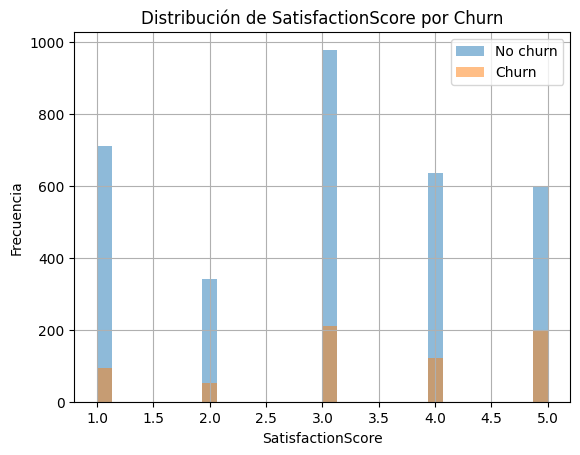

In [91]:
import matplotlib.pyplot as plt
from src.plots import plot_hist, plot_hist_by_churn

plot_hist_by_churn(df, "SatisfactionScore")
plt.show()



In [90]:
df.groupby("Churn")["SatisfactionScore"].mean()

Churn
0    3.020814
1    3.415430
Name: SatisfactionScore, dtype: float64

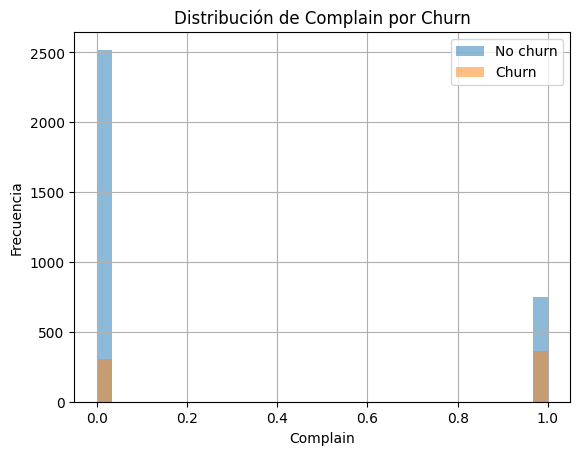

In [92]:
import matplotlib.pyplot as plt
from src.plots import plot_hist, plot_hist_by_churn

plot_hist_by_churn(df, "Complain")
plt.show()

In [67]:
df.groupby("Churn")["Complain"].mean()

Churn
0    0.228956
1    0.541543
Name: Complain, dtype: float64

Los clientes churn presentan más quejas (0.54 en promedio) que los clientes no churn (0.22 en promedio). Lo que quiere decir que los clientes que se quejan son los que más tienden a abandonar el negocio.

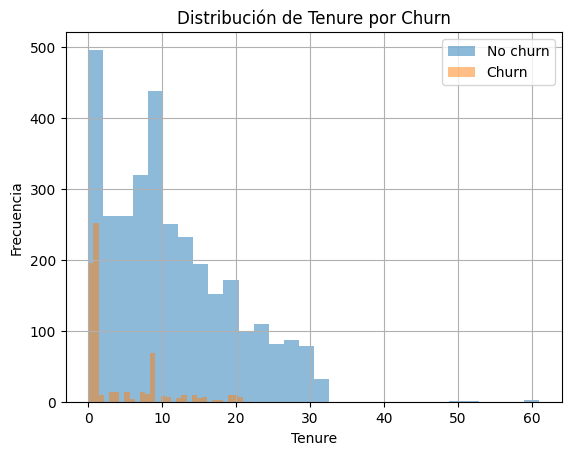

In [93]:
import matplotlib.pyplot as plt
from src.plots import plot_hist, plot_hist_by_churn

plot_hist_by_churn(df, "Tenure")
plt.show()

In [68]:
df.groupby("Churn")["Tenure"].mean()

Churn
0    11.330579
1     3.715134
Name: Tenure, dtype: float64

Se observa que, los clientes no churn tienen una antiguedad de 11.33 en promedio mucho mayor que los clientes churn con 3.72 en promedio, lo que significa que los clientes nuevos son los que están más en riesgo de abandonar el negocio.

In [74]:
df.groupby("Churn")["WarehouseToHome"].mean()

Churn
0    15.330272
1    16.789318
Name: WarehouseToHome, dtype: float64

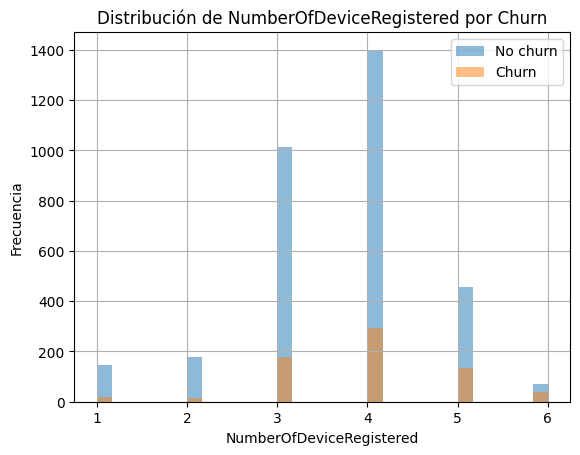

In [95]:
import matplotlib.pyplot as plt
from src.plots import plot_hist, plot_hist_by_churn

plot_hist_by_churn(df, "NumberOfDeviceRegistered")
plt.show()

In [75]:
df.groupby("Churn")["NumberOfDeviceRegistered"].mean()

Churn
0    3.629324
1    3.921365
Name: NumberOfDeviceRegistered, dtype: float64

In [76]:
df.groupby("Churn")["NumberOfAddress"].mean()

Churn
0    4.191001
1    4.464392
Name: NumberOfAddress, dtype: float64

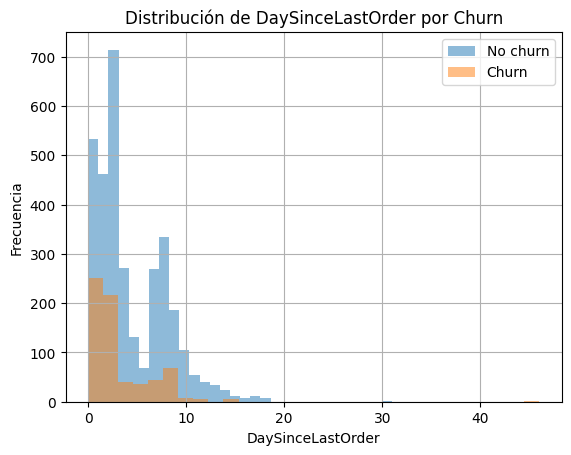

In [94]:
import matplotlib.pyplot as plt
from src.plots import plot_hist, plot_hist_by_churn

plot_hist_by_churn(df, "DaySinceLastOrder")
plt.show()

In [77]:
df.groupby("Churn")["DaySinceLastOrder"].mean()

Churn
0    4.702785
1    3.218101
Name: DaySinceLastOrder, dtype: float64

In [78]:
df.groupby("Churn")["CashbackAmount"].mean()

Churn
0    180.286847
1    159.357285
Name: CashbackAmount, dtype: float64

Se observa que la variable churn está influenciada principalmente por las variables "tenure" y "complain". Quiere decir que los clientes churn tienen una antiguedad significativamente menor y presentan más quejas que los cliente no churn. 
Por otro lado, la variables "satisfactionScore" no presente concordancia con el negocio o se requiere un análisis más profundo, ya que los clientes churn presentan más satifisfacción que los clientes no churn. 

In [69]:
pd.crosstab(df["Churn"],df["PreferedOrderCat"],normalize="index")

PreferedOrderCat,Fashion,Grocery,Laptop & Accessory,Mobile,Mobile Phone,Others
Churn,,,,,,
0,0.150291,0.079890,0.402816,0.122436,0.193450,0.051117
1,0.139466,0.017804,0.210682,0.235905,0.378338,0.017804


In [70]:
pd.crosstab(df["Churn"],df["MaritalStatus"],normalize="index")

MaritalStatus,Divorced,Married,Single
Churn,,,
0,0.149066,0.558616,0.292317
1,0.132047,0.341246,0.526706


# 6. Insights y próximos pasos

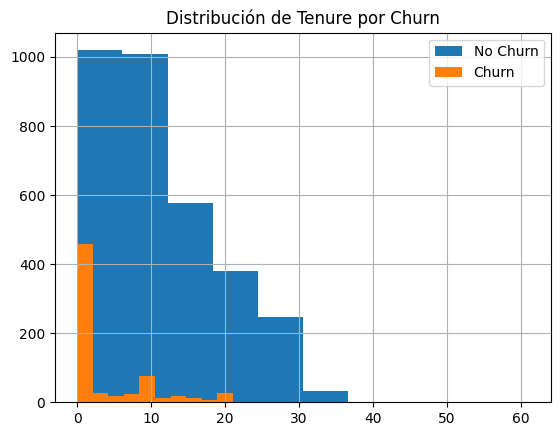

In [71]:
df[df["Churn"]==0]["Tenure"].hist()
df[df["Churn"]==1]["Tenure"].hist()
plt.legend(["No Churn","Churn"])
plt.title("Distribución de Tenure por Churn")
plt.show()

Los clientes con menor antigüedad presentan mayor probabilidad de churn, por lo que que la retención temprana es un factor crítico.

Text(0.5, 1.0, 'Distribución ')

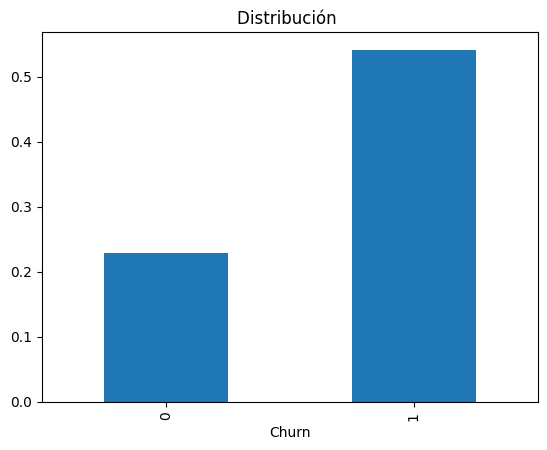

In [72]:
df.groupby("Churn")["Complain"].mean().plot(kind="bar")
plt.title("Distribución ")

Los clientes que presentan quejas tienen mayor probabilidad de churn, lo que indica que la experiencia negativa impacta directamente en la retención.

<Axes: xlabel='Churn'>

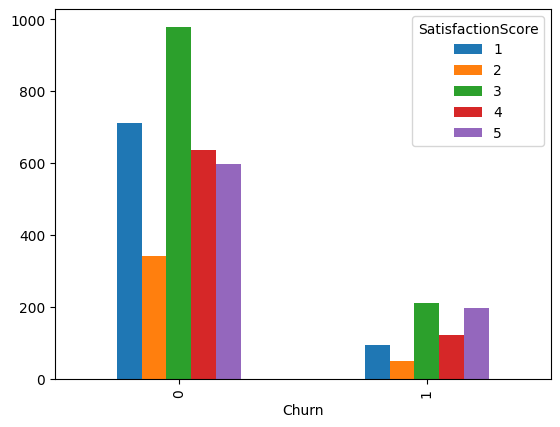

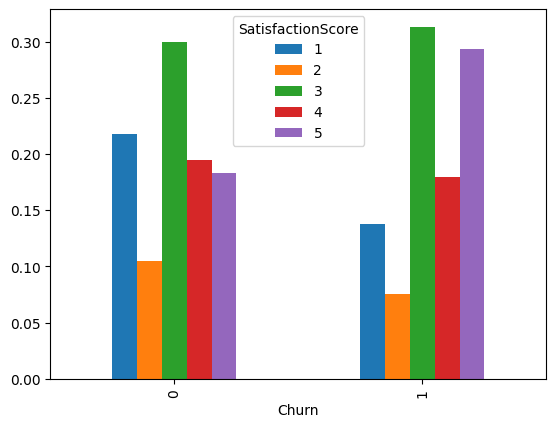

In [73]:
df.groupby(["Churn","SatisfactionScore"]).size().unstack().plot(kind="bar")
df.groupby("Churn")["SatisfactionScore"].value_counts(normalize=True).unstack().plot(kind="bar")

La variable SatisfactionScore presenta una distribución similar entre clientes churn y no churn. Aunque el grupo no churn tiene mayores frecuencias absolutas, esto se debe al tamaño del grupo y no a una diferencia real en el comportamiento. Por lo tanto, esta variable no parece ser un predictor fuerte del churn y no se tomará en cuenta para las fases posteriores, como el preprocesamiento del dataset.